In [1]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV


import pandas as pd
import numpy as np

import joblib

import utils as ut

In [26]:
def load_and_shuffle_data(l_swap_colnames, is_testcase):
    df_itc = pd.read_csv("data/full-data.csv")
    # make participant ids unique (i.e., they were re-used across sessions, but likely not from the same participant)
    df_itc = ut.unique_participant_ids(df_itc)
    df_itc["trial_id"] = df_itc.groupby("sid_unique").cumcount() + 1
    df_itc = ut.shift_y(df_itc)

    n_participants_total = df_itc["sid_unique"].nunique()
    l_pairs_colnames = [["right_val", "left_val"], ["right_time", "left_time"]]
    
    # note. all participants provided exactly 195 trials
    n_trials = 195
    n_trials_train = 130
    
    # ===================== Prepare Data =====================
    
    col_pid = ["sid_unique"]
    cols_x = ["right_time", "right_val", "left_time", "left_val"]
    col_y = ["right_picked"]
    col_y_shifted = ["right_picked_prev"]
    
    # zscale X
    # df_itc[cols_x] = df_itc[cols_x].apply(zscore)
    
    # compute z scores across pairs of columns
    df_itc = ut.zscore_pairs(df_itc, l_pairs_colnames)
    df_itc_original = df_itc.copy()


    # shuffle more variables if specified
    if len(l_swap_colnames[0]) > 0:
        for idx, colnames in enumerate(l_swap_colnames):
            df_itc = ut.swap_two_cols(df_itc, colnames, idx)

    dict_itc = ut.split_and_format(df_itc, "original", splittype="first_vs_second_half", n_trial_split=n_trials_train,
        col_pid=col_pid, cols_x=cols_x, col_y=col_y, col_y_shifted=col_y_shifted
    )

    nobs_train = dict_itc["X_train"].shape[0] * dict_itc["X_train"].shape[1]
    nobs_dev = dict_itc["X_dev"].shape[0] * dict_itc["X_dev"].shape[1]

    X_train = np.reshape(dict_itc["X_train"].detach().numpy(), (nobs_train, 5), "C")[:,0:4]
    X_dev = np.reshape(dict_itc["X_dev"].detach().numpy(), (nobs_dev, 5), "C")[:,0:4]

    y_train = np.ravel(np.reshape(dict_itc["y_train"].detach().numpy(), (nobs_train, 1), "C"))
    y_dev = np.ravel(np.reshape(dict_itc["y_dev"].detach().numpy(), (nobs_dev, 1), "C"))

    if is_testcase:
        X_train = X_train[0:50000,:]
        X_dev = X_dev[0:50000,:]
        y_train = y_train[0:50000,]
        y_dev = y_dev[0:50000,]

    return X_train, y_train, X_dev, y_dev, df_itc_original

## hyperparameter search over time and value

In [27]:
# just for testing purposes (True) or run on all data (False)
is_testcase = True
# should models be fitted (True) or loaded (False)?
fit_models = True

l_swap_colnames = [[]]
X_train, y_train, X_dev, y_dev, df_itc_original = load_and_shuffle_data(l_swap_colnames, is_testcase)

In [28]:
param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.05, 0.1, 0.15],
    "max_depth": [2, 3, 4]
}

model_full = GradientBoostingClassifier()

grid_full = GridSearchCV(
    estimator=model_full,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring="neg_log_loss",  # or another metric
    n_jobs=-1            # use all CPU cores
)

if fit_models:
    grid_full.fit(X_train, y_train)
    joblib.dump(grid_full, "models/gridsearch-time-and-value.pkl")
else:
    grid_full = joblib.load("models/gridsearch-time-and-value.pkl")

In [29]:
best_model_full = grid_full.best_estimator_
y_dev_pred = best_model_full.predict(X_dev)
y_train_pred = best_model_full.predict(X_train)
df_train_preds_full = pd.DataFrame({"y_train_true":y_train, "y_train_pred":y_train_pred}) 
df_train_preds_full["is_correct"] = df_train_preds_full["y_train_true"] == df_train_preds_full["y_train_pred"]
df_dev_preds_full = pd.DataFrame({"y_dev_true":y_dev, "y_dev_pred":y_dev_pred})
df_dev_preds_full["is_correct"] = df_dev_preds_full["y_dev_true"] == df_dev_preds_full["y_dev_pred"]

In [30]:
print(
    "TIME AND VALUE:\n",
    "train accuracy: ", np.round(df_train_preds_full["is_correct"].mean(), 3), 
    "\ndev accuracy: ", np.round(df_dev_preds_full["is_correct"].mean(), 3)
)

TIME AND VALUE:
 train accuracy:  0.833 
dev accuracy:  0.844


## hyperparameter search over time only

In [31]:
# just for testing purposes (True) or run on all data (False)
is_testcase = True
# should models be fitted (True) or loaded (False)?
fit_models = True

l_swap_colnames = [["right_val", "left_val"]]#["right_time", "left_time"], 
X_train, y_train, X_dev, y_dev, df_itc_original = load_and_shuffle_data(l_swap_colnames, is_testcase)

In [32]:
X_train[0:5,:]

array([[ 1.09089855, -0.22111252,  0.0748864 , -0.22128175],
       [-0.94112574, -0.21851764,  1.47795079, -0.21005608],
       [-0.50569197, -0.13672252, -0.60245503, -0.0944147 ],
       [-0.94112574, -0.13672252, -0.89274421, -0.12826096],
       [-0.60245503, -0.2166843 , -0.40892891, -0.21710738]])

In [33]:
#X_train_time = X_train[:,[0,2]].copy()
#X_dev_time = X_dev[:,[0,2]].copy()

In [34]:
model_time = GradientBoostingClassifier()
grid_time = GridSearchCV(
    estimator=model_time,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring="neg_log_loss",  # or another metric
    n_jobs=-1            # use all CPU cores
)
if fit_models:
    grid_time.fit(X_train, y_train)
    joblib.dump(grid_time, "models/gridsearch-time-only.pkl")
else:
    grid_time = joblib.load("models/gridsearch-time-only.pkl")

In [35]:
best_model_time = grid_time.best_estimator_
y_dev_pred = best_model_time.predict(X_dev)
y_train_pred = best_model_time.predict(X_train)
df_train_preds_time = pd.DataFrame({"y_train_true":y_train, "y_train_pred":y_train_pred})
df_train_preds_time["is_correct"] = df_train_preds_time["y_train_true"] == df_train_preds_time["y_train_pred"]
df_dev_preds_time = pd.DataFrame({"y_dev_true":y_dev, "y_dev_pred":y_dev_pred})
df_dev_preds_time["is_correct"] = df_dev_preds_time["y_dev_true"] == df_dev_preds_time["y_dev_pred"]

In [36]:
print(
    "ONLY TIME:\n",
    "train accuracy: ", np.round(df_train_preds_time["is_correct"].mean(), 3), 
    "\ndev accuracy: ", np.round(df_dev_preds_time["is_correct"].mean(), 3)
)

ONLY TIME:
 train accuracy:  0.828 
dev accuracy:  0.843


## hyperparameter search over value only

In [37]:
#X_train_value = X_train[:,[1,3]]
#X_dev_value = X_dev[:,[1,3]]

In [38]:
# just for testing purposes (True) or run on all data (False)
is_testcase = True
# should models be fitted (True) or loaded (False)?
fit_models = True

l_swap_colnames = [["right_time", "left_time"]]#, ["right_val", "left_val"]
X_train, y_train, X_dev, y_dev, df_itc_original = load_and_shuffle_data(l_swap_colnames, is_testcase)

In [39]:
model_value = GradientBoostingClassifier()
grid_value = GridSearchCV(
    estimator=model_value,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring="neg_log_loss",  # or another metric
    n_jobs=-1            # use all CPU cores
)
if fit_models:
    grid_value.fit(X_train, y_train)
    joblib.dump(grid_value, "models/gridsearch-value-only.pkl")
else:
    grid_value = joblib.load("models/gridsearch-value-only.pkl")

In [40]:
df_itc_original.head()

,Unnamed: 0,right_time,right_val,left_time,left_val,att_check,condition,time_diff,sooner_time,relative_value_diff,absolute_value_diff,right_picked,sid,month,sid_continue,sid_unique,trial_id,right_picked_prev
0,0,1.090899,-0.221113,0.074886,-0.221282,0,4,21,21,4.0,2.0,1,1,March,0.0,1,1,0
1,1,-0.941126,-0.218518,1.477951,-0.210056,0,4,50,0,4.0,100.0,0,1,March,0.0,1,2,1
2,2,-0.505692,-0.094415,-0.602455,-0.136723,0,4,2,7,1.5,500.0,1,1,March,0.0,1,3,0
3,3,-0.941126,-0.136723,-0.892744,-0.128261,0,4,1,0,1.1,100.0,0,1,March,0.0,1,4,1
4,4,-0.602455,-0.217107,-0.408929,-0.216684,0,4,4,7,1.1,5.0,0,1,March,0.0,1,5,0


In [41]:
X_train[0:5,:]

array([[ 1.09089855, -0.22111252,  0.0748864 , -0.22128175],
       [-0.94112574, -0.21851764,  1.47795079, -0.21005608],
       [-0.60245503, -0.0944147 , -0.50569197, -0.13672252],
       [-0.94112574, -0.13672252, -0.89274421, -0.12826096],
       [-0.40892891, -0.21710738, -0.60245503, -0.2166843 ]])

In [42]:
best_model_value = grid_value.best_estimator_
y_dev_pred = best_model_value.predict(X_dev)
y_train_pred = best_model_value.predict(X_train)
df_train_preds_value = pd.DataFrame({"y_train_true":y_train, "y_train_pred":y_train_pred}) 
df_train_preds_value["is_correct"] = df_train_preds_value["y_train_true"] == df_train_preds_value["y_train_pred"]
df_dev_preds_value = pd.DataFrame({"y_dev_true":y_dev, "y_dev_pred":y_dev_pred})
df_dev_preds_value["is_correct"] = df_dev_preds_value["y_dev_true"] == df_dev_preds_value["y_dev_pred"]

In [43]:
print(
    "ONLY VALUE:\n",
    "train accuracy: ", np.round(df_train_preds_value["is_correct"].mean(), 3), 
    "\ndev accuracy: ", np.round(df_dev_preds_value["is_correct"].mean(), 3)
)

ONLY VALUE:
 train accuracy:  0.825 
dev accuracy:  0.843


In [44]:
grid_full.best_score_

-0.3897910269948534

In [45]:
grid_value.best_score_

-0.42041598578536776

In [46]:
grid_time.best_score_

-0.41779673157938324

## Hyperparameter Search with everything shuffled

In [21]:
# just for testing purposes (True) or run on all data (False)
is_testcase = True
# should models be fitted (True) or loaded (False)?
fit_models = True

l_swap_colnames = [["right_time", "left_time"], ["right_val", "left_val"]]#
X_train, y_train, X_dev, y_dev, df_itc_original = load_and_shuffle_data(l_swap_colnames, is_testcase)

In [22]:
model_random = GradientBoostingClassifier()

grid_random = GridSearchCV(
    estimator=model_random,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring="accuracy",  # or another metric
    n_jobs=-1            # use all CPU cores
)

if fit_models:
    grid_random.fit(X_train, y_train)
    joblib.dump(grid_random, "models/gridsearch-time-and-value.pkl")
else:
    grid_random = joblib.load("models/gridsearch-time-and-value.pkl")

In [23]:
best_model_random = grid_random.best_estimator_
y_dev_pred = best_model_random.predict(X_dev)
y_train_pred = best_model_random.predict(X_train)
df_train_preds_random = pd.DataFrame({"y_train_true":y_train, "y_train_pred":y_train_pred}) 
df_train_preds_random["is_correct"] = df_train_preds_random["y_train_true"] == df_train_preds_random["y_train_pred"]
df_dev_preds_random = pd.DataFrame({"y_dev_true":y_dev, "y_dev_pred":y_dev_pred})
df_dev_preds_random["is_correct"] = df_dev_preds_random["y_dev_true"] == df_dev_preds_random["y_dev_pred"]

In [24]:
print(
    "ALL SHUFFLED:\n",
    "train accuracy: ", np.round(df_train_preds_random["is_correct"].mean(), 3), 
    "\ndev accuracy: ", np.round(df_dev_preds_random["is_correct"].mean(), 3)
)

ALL SHUFFLED:
 train accuracy:  0.516 
dev accuracy:  0.5


## Check time
idea is to verify that shuffling one variable with two cols and only using that variable leads to chance performance

In [25]:
# just for testing purposes (True) or run on all data (False)
is_testcase = True
# should models be fitted (True) or loaded (False)?
fit_models = True

# swap everything
l_swap_colnames = [["right_time", "left_time"], ["right_val", "left_val"]]#[[]]#
X_train, y_train, X_dev, y_dev, df_itc_original = load_and_shuffle_data(l_swap_colnames, is_testcase)
# but then only select two cols
X_train = X_train[:, [0, 2]]
X_dev = X_dev[:, [0, 2]]

In [26]:
model_check_time = GradientBoostingClassifier()

grid_check_time = GridSearchCV(
    estimator=model_check_time,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring="accuracy",  # or another metric
    n_jobs=-1            # use all CPU cores
)

if fit_models:
    grid_check_time.fit(X_train, y_train)
    joblib.dump(grid_check_time, "models/gridsearch-check-time.pkl")
else:
    grid_check_time = joblib.load("models/gridsearch-check-time.pkl")

In [27]:
best_model_check_time = grid_check_time.best_estimator_
y_dev_pred = best_model_check_time.predict(X_dev)
y_train_pred = best_model_check_time.predict(X_train)
df_train_preds_check_time = pd.DataFrame({"y_train_true":y_train, "y_train_pred":y_train_pred}) 
df_train_preds_check_time["is_correct"] = df_train_preds_check_time["y_train_true"] == df_train_preds_check_time["y_train_pred"]
df_dev_preds_check_time = pd.DataFrame({"y_dev_true":y_dev, "y_dev_pred":y_dev_pred})
df_dev_preds_check_time["is_correct"] = df_dev_preds_check_time["y_dev_true"] == df_dev_preds_check_time["y_dev_pred"]

In [28]:
print(
    "TIME SHUFFLED AND USED:\n",
    "train accuracy: ", np.round(df_dev_preds_check_time["is_correct"].mean(), 3), 
    "\ndev accuracy: ", np.round(df_dev_preds_check_time["is_correct"].mean(), 3)
)

TIME SHUFFLED AND USED:
 train accuracy:  0.501 
dev accuracy:  0.501


## Check Value

In [29]:
# just for testing purposes (True) or run on all data (False)
is_testcase = True
# should models be fitted (True) or loaded (False)?
fit_models = True

# swap everything
l_swap_colnames = [["right_time", "left_time"], ["right_val", "left_val"]]#[[]]#
X_train, y_train, X_dev, y_dev, df_itc_original = load_and_shuffle_data(l_swap_colnames, is_testcase)
# but then only select two cols
X_train = X_train[:, [1, 3]]
X_dev = X_dev[:, [1, 3]]

In [30]:
model_check_value = GradientBoostingClassifier()

grid_check_value = GridSearchCV(
    estimator=model_check_value,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring="accuracy",  # or another metric
    n_jobs=-1            # use all CPU cores
)

if fit_models:
    grid_check_value.fit(X_train, y_train)
    joblib.dump(grid_check_value, "models/gridsearch-check-value.pkl")
else:
    grid_check_value = joblib.load("models/gridsearch-check-value.pkl")

In [31]:
best_model_check_value = grid_check_value.best_estimator_
y_dev_pred = best_model_check_value.predict(X_dev)
y_train_pred = best_model_check_value.predict(X_train)
df_train_preds_check_value = pd.DataFrame({"y_train_true":y_train, "y_train_pred":y_train_pred}) 
df_train_preds_check_value["is_correct"] = df_train_preds_check_value["y_train_true"] == df_train_preds_check_value["y_train_pred"]
df_dev_preds_check_value = pd.DataFrame({"y_dev_true":y_dev, "y_dev_pred":y_dev_pred})
df_dev_preds_check_value["is_correct"] = df_dev_preds_check_value["y_dev_true"] == df_dev_preds_check_value["y_dev_pred"]

In [32]:
print(
    "VALUE SHUFFLED AND USED:\n",
    "train accuracy: ", np.round(df_dev_preds_check_value["is_correct"].mean(), 3), 
    "\ndev accuracy: ", np.round(df_dev_preds_check_value["is_correct"].mean(), 3)
)

VALUE SHUFFLED AND USED:
 train accuracy:  0.499 
dev accuracy:  0.499


## Compare Predictions between Value and Time Models

In [33]:
df_preds_separate = pd.merge(df_dev_preds_time, df_dev_preds_value, left_index=True, right_index=True, suffixes=["_time", "_value"])

In [34]:
df_preds_separate["both_correct"] = df_preds_separate["is_correct_time"] & df_preds_separate["is_correct_value"]

In [35]:
df_preds_separate.is_correct_time.mean()

0.8427

In [36]:
df_preds_separate.is_correct_value.mean()

0.84314

In [37]:
df_preds_separate.both_correct.mean()

0.83384

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_2057594/3660623524.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=12)
/tmp/ipykernel_2057594/3660623524.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)


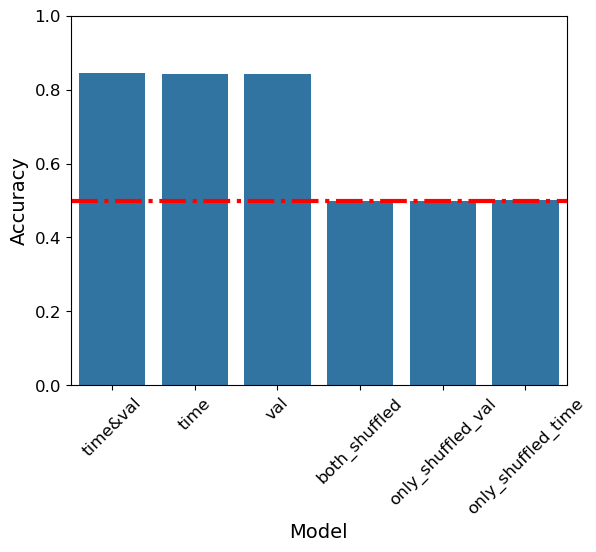

In [39]:
df_results = pd.DataFrame({
    "idx":0,
    "time&val":df_dev_preds_full["is_correct"].mean(),
    "time":df_dev_preds_time["is_correct"].mean(),
    "val":df_dev_preds_value["is_correct"].mean(),
    "both_shuffled":df_dev_preds_random["is_correct"].mean(),
    "only_shuffled_val":df_dev_preds_check_value["is_correct"].mean(),
    "only_shuffled_time":df_dev_preds_check_time["is_correct"].mean(),
}, index=range(1))
df_results = df_results.melt(id_vars="idx")
f, ax = plt.subplots(1)
sns.barplot(df_results, x="variable", y="value", ax=ax)
ax.set_ylim(0, 1)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
ax.set_xlabel("Model", fontsize=14)
ax.set_ylabel("Accuracy", fontsize=14)
_ = ax.axhline(y=.5, c="red", linewidth=3, linestyle="-.")